# `artlib` Tutorial

This is a notebook tutorializing the usage of the `artlib` package!

## Resources/Links

The `artlib` package features a swath of documentation both in the repo's README file and its hosted documentation on readthedocs.
Below are links to these resources for reference:

- [GitHub Repo](https://github.com/NiklasMelton/AdaptiveResonanceLib)
- [Documentation](https://adaptiveresonancelib.readthedocs.io)

## Data

First, we should load some data!
Here, we will use the quintessential UCI Iris dataset once again as a relatively simple example.
One way that we can reduce boilerplate code here is by wrapping the code loading into a function that we dispatch onto both the `train` and `test` splits, since the same transforms and procedures are used for both.

To do that, lets define some data containers and loading functions:

In [1]:
# Ubiquitous convention for importing numpy to handle arrays
import numpy as np

# Dataclass for a structured way of passing around a dataset
from dataclasses import dataclass

# Create a simple container for a supervised dataset (samples and targets)
@dataclass
class SupervisedDataset:
    x: np.array
    y: np.array

    # Show just the shapes of the arrays when printing this object
    def __repr__(self):
        return f"SupervisedDataset(x: {self.x.shape}, y: {self.y.shape})"

With this container, we can create an explicit supervised dataset wrapper for the UCI Iris dataset.
Lets load it up with the following function:

In [2]:
# Pandas for loading and manipulating data as a DataFrame
import pandas as pd
# For loading the iris dataset as an example
from sklearn.datasets import load_iris

# Constructor for a SupervisedDataSplit, loading the iris dataset
def load_data() -> SupervisedDataset:
    # Load the iris dataset as a DataFrame
    iris = load_iris(as_frame=True)
    # Extract the DataFrame from the dictionary the loader provides
    data = iris['frame']
    y = data.pop('target')

    # Get the numpy arrays from the data and put it in a container
    full_dataset = SupervisedDataset(
        data.to_numpy(),
        y.to_numpy(),
    )

    # Return the data as a DataFrame
    return full_dataset

# Load the data
full_data = load_data()

# Print the string representation of the data
full_data

SupervisedDataset(x: (150, 4), y: (150,))

Now, we have a data container `full_data` that is a *supervised dataset*, in that it contains data samples along with target values.

Now, we'll be doing *unsupervised* learning (i.e., clustering) here along with *supervised* learning (i.e., targeting supervised labels); this `full_data` container will serve us well for both here.

However, in the supervised case, we should also make one more amendment, namely that of a *train/test split*.
This is where we take a portion of the full dataset and hold it to the side so that we can test our accuracy on previously-seen data.
It wouldn't be fair (or really worthwhile in any way) if we got to cheat and give the model access to the testing data in advance!
To do this, we'll utilize another `scikit-learn` utility called `train_test_split` and slap it all into another container to keep organized.

<div class="alert alert-block alert-info"> <b>NOTE</b>:
Why another data container, you might ask?
Because it's tiresome and messy creating a new variable for every permutation of every part of this dataset, and I'm the one in charge of writing this notebook, thank you very much!
</div>

In [3]:
# Handy tool for splitting a dataset
from sklearn.model_selection import train_test_split

# Create a container that is a supervised train/test split
@dataclass
class SupervisedDataSplit:
    train: SupervisedDataset
    test: SupervisedDataset

    def __repr__(self):
        return f"SupervisedDataSplit(\n\ttrain={self.train}\n\ttest={self.test}\n)"

# Write a function that takes the full dataset and splits it into two
def split_data(data:SupervisedDataset) -> SupervisedDataSplit:
    X_train, X_test, y_train, y_test = train_test_split(
        data.x,
        data.y,
        test_size=0.3,
        random_state=42,
    )

    # Construct a container for the supervised train/test splits
    data_container = SupervisedDataSplit(
        SupervisedDataset(X_train, y_train),
        SupervisedDataset(X_test, y_test),
    )
    return data_container

# Get a train/test split from the full data
data = split_data(full_data)
# Show that data split to see the resulting dimensions
print(data)

SupervisedDataSplit(
	train=SupervisedDataset(x: (105, 4), y: (105,))
	test=SupervisedDataset(x: (45, 4), y: (45,))
)


Now that we have the data, lets actually use `artlib` to instantiate, train, and test some ART modules!
First, we'll do an unsupervised variant and visualize its clusters, then we'll follow up with supervised learning and actually get some testing accuracies!

## Unsupervised: FuzzyART

The representative real-valued version of unsupervised ART modules is `FuzzyART`, so lets start off by importing its definition from the library and setting it up!

In [4]:
# Import the FuzzyART module
from artlib import FuzzyART

# Define a FuzzyART constructor based upon metadata of the full dataset
def get_FuzzyART(full_data: SupervisedDataset):
    # Initialize the Fuzzy ART model
    model = FuzzyART(rho=0.6, alpha = 0.0, beta=1.0)

    # Specify the dimension of the data in advance (infer from the data)
    n_dim = full_data.x.shape[1]

    # Tell the model the full data limits for normalization
    lower_bounds = np.min(full_data.x, axis=0)
    upper_bounds = np.max(full_data.x, axis=0)
    model.set_data_bounds(lower_bounds, upper_bounds)
    return model

# Run the function to instantiate and setup a FuzzyART model
model = get_FuzzyART(full_data)
# Print the string representation of the model
print(model)

FuzzyART(alpha=0.0, beta=1.0, rho=0.6)


Very importantly, we should note that we told the model in advance the length of the input vectors and the bounds of those samples in each feature dimension via the `set_data_bounds` method.
If we are training incrementally, this is pretty important information to know in advance.
The `artlib` module infers what it needs to if you are just training in one batch (like what we are doing here), but its important to note that this is information that the model can't possibly infer if you are training incrementally, so this is how we specify that information in advance.

In practical applications, this usually means that we specify that the FuzzyART module has normalized input samples in $[0, 1]$, and then it is up to us to do input preprocessing to make sure that those samples are actually normalized before feeding them into the `FuzzyART` module.

Now, let's train the model!

### Training

We use the `prepare_data` method of the model to do the linear normalization and complement coding that the `FuzzyART` module requires.
If we specified that the features can fall somewhere outside of $[0, 1]$ in the previous step, this is where it is handled (in addition to and followed by the complement coding step where $x \gets [x, 1-x]$).

Then, we fit the data with the `fit` method:

In [5]:
# Preprocess the data (normalize and complement code)
train_X_prep = model.prepare_data(data.train.x)
# Fit the model
model.fit(train_X_prep)
# Check out now many clusters are generated
print(f"Number of categories: {model.n_clusters}")
print(f"Number of training samples: {len(full_data.y)}")

Number of categories: 6
Number of training samples: 150


Look at that!
We got fewer categories than the number of samples that we trained on, meaning that we clustered the data!
We clustered the 150 samples in the dataset into 6 different clusters, which means that we successfully...did some clustering!

<div class="alert alert-block alert-info"> <b>NOTE</b>:
It is also important to note that if we wanted to train incrementally, we would use the `partial_fit` function; this is because under the hood the `fit` function overwrites the underlying weights and starts from scratch, while `partial_fit` doesn't overwrite the weights!
This would look like the following:
</div>

In [6]:
# Create a new model as an example
incremental_model = get_FuzzyART(full_data)
# Train on the dataset incrementally, one sample at a time
for _, x in enumerate(full_data.x):
    # prepare_data still expects a 2D sample "matrix" even though enumerate gives us a 1D
    local_sample = np.expand_dims(x, axis=0)
    # Preprocess the sample
    train_X_prep = model.prepare_data(local_sample)
    # Run the "partial_fit" method to train incrementally
    incremental_model.partial_fit(train_X_prep)

# Print the clustering "results" as a sanity check
print(f"Incremental: n_categories = {incremental_model.n_clusters}")
print(f"Batch: n_categories = {model.n_clusters}")

Incremental: n_categories = 6
Batch: n_categories = 6


We see that the incremental training method gives us the same number of clusters.
That is actually one of the unique things about ART algorithms!
They are incremental under the hood, so there's no special "information" that the model gets from having all of the data available up front in batch mode, which is why they perform so well in incremental learning applications.

### Evaluation

Let's see how the model clustered the data!
First, let's "classify" the full dataset (i.e., get the internal labels prescribed by the clustering process)


In [7]:
# Preprocess the data again
test_X_prep = model.prepare_data(full_data.x)
# Predict data labels
y_hats = model.predict(test_X_prep)
# Show the unique internal labels for each category
np.unique(y_hats)

array([0, 1, 2, 3, 4, 5])

Next, lets try to plot the clustering results!
To do this, we will first project the 4D Iris data into two dimensions so that we can visualize it using the TSNE method:

In [8]:
# For 2D visualization
from sklearn.manifold import TSNE

# Now, we initialize a TSNE module with its own set of hyperparameters for how it will be "trained" to create a mapping between the 4d data and its 2d projection.
t_sne = TSNE(
    n_components=2,
    perplexity=10,
    init="random",
    max_iter=250,
    random_state=0,
)

# Fit the TSNE to the data, and return those transformed points
S_t_sne = t_sne.fit_transform(full_data.x)

Now that we have 2D projected values for the samples, we can plot those samples and color them according to the cluster labels to see where the `FuzzyART` module "believes that the clusters" are in the input space.
The next cell just defines some plotting functions to do so, where we put the `FuzzyART` labels on one side and the "true labels" on the other.

Again, this is the clustering/unsupervised example, so we aren't expecting these results to align or even be a metric of accuracy; this is just to see if `FuzzyART` found structures in the data that in any way line up with what the supervised labels say there should be!

In [9]:
# The most common way of importing matplotlib for plotting in Python
from matplotlib import pyplot as plt
# For manipulating axis tick locations
from matplotlib import ticker

# Scatters points TSNE points and colors according to label
def add_2d_scatter(ax, points, colors, title=None):
    x, y = points
    ax.scatter(x, y, s=50, c=colors, alpha=0.8)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

# Generate a side-by-side comparison plot
def plot_side_by_side_2d(x, y1, y2, t1, t2, ttop):
    cmap = plt.get_cmap('tab10')
    fig, (ax1, ax2) = plt.subplots(1,2,
        figsize=(6, 3),
        facecolor="white",
        constrained_layout=True,
    )
    fig.suptitle(ttop, size=16)
    colors = [cmap(i) for i in y1]
    add_2d_scatter(ax1, x, colors)
    ax1.set_title(t1, size=16)

    colors = [cmap(i) for i in y2]
    add_2d_scatter(ax2, x, colors)
    ax2.set_title(t2, size=16)
    plt.show()

Now that we have our plotting utilities defined, lets generate that plot and see what we find!

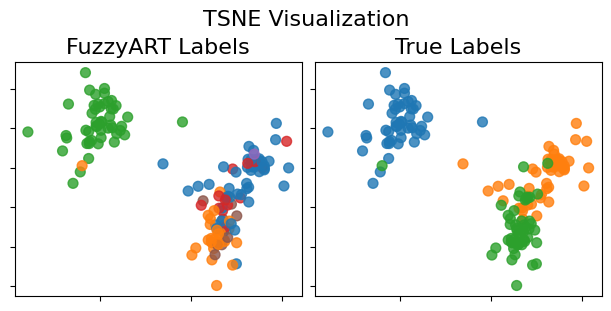

In [10]:
# Generate the plot
plot_side_by_side_2d(
    S_t_sne.T,              # The TSNE 2D projections
    y_hats,                 # The clustered labels
    full_data.y,            # The true labels
    "FuzzyART Labels",
    "True Labels",
    "TSNE Visualization",
)

Sweet!
We see that at our selected vigilance parameter $\rho=0.6$, `FuzzyART` finds the majority of the large-scale structures in the data correctly while somewhat struggling on some of overlapping and singleton samples.

Now then, let's see how we can use supervised labels in the loop to improve our performance!

## Supervised: FuzzyARTMAP

In many scenarios, you don't have labels to do supervised learning, which is where algorithms like `FuzzyART` come in handy.
In some other scenarios, you may indeed be lucky enough to have ground truth labels!
The supervised equivalents of `ART` modules are known as `ARTMAP` modules; this is because in the original ART literature, supervised learning is accomplished through "mapping" between the clusters of two separate ART clustering processes (hence ARTMAP).
This is generically defined as a "supervised" mapping between any two input vectors $\bar{x}$ and $\bar{y}$, but these models are easily adapted for integer-valued supervised labels $y \in \mathbb{N}$.
Because of the ubiquity of integer-valued supervised labels, this is the style of module that we will use unless specified otherwise.

First, we import and instantiate a new `FuzzyARTMAP` module:

In [11]:
# Import the FuzzyART module
from artlib import FuzzyARTMAP

# Initialize the FuzzyARTMAP model directly
model = FuzzyARTMAP(rho=0.6, alpha = 0.0, beta=1.0)

Super easy!

Now, we still want to have the `FuzzyART` part of the module set up with the correct input dimensions, etc., so we can actually instantiate our `FuzzyARTMAP` module through a `SimpleARTMAP` wrapper of our already set up `FuzzyART` module like so:  

In [12]:
# Import the FuzzyART module
from artlib import SimpleARTMAP

# Initialize the set up FuzzyART model using the function we defined before
model_a = get_FuzzyART(full_data)

# Slap it inside a supervised SimpleARTMAP
model = SimpleARTMAP(model_a)

# Print the string representation of the model
print(model)

SimpleARTMAP(module_a=FuzzyART(alpha=0.0, beta=1.0, rho=0.6))


If we wanted to set up the `FuzzyART` bounds inside of the `FuzzyARTMAP` module, then we could still do it after the fact with:

In [13]:
# Specify the dimension of the data in advance (infer from the data)
n_dim = full_data.x.shape[1]

# Tell the model the full data limits for normalization
lower_bounds = np.min(full_data.x, axis=0)
upper_bounds = np.max(full_data.x, axis=0)
# Internally, the FuzzyART module is assigned to the module_a variable
model.module_a.set_data_bounds(lower_bounds, upper_bounds)

Now we are ready to do some supervised training!

### Training

Just as before, we can train `FuzzyARTMAP` in batch (passing all the data at once), incrementally (once sample at a time), or even in minibatches by using the incremental methods with small subsets of the data.
Since we already demonstrated the incremental methods, we will just train in batch mode.

To pass the supervised labels, we simply pass the keyword argument `y=<your-labels-matrix>` in the `fit` method like so:

In [14]:
# Preprocess the data (normalize and complement code)
train_X_prep = model.prepare_data(data.train.x)
# Fit the model
model.fit(train_X_prep, y=data.train.y)
# Check out now many prototypes are generated
print(f"Number of categories: {model.n_clusters}")

Number of categories: 7


<div class="alert alert-block alert-info"> <b>NOTE</b>:
Since we are doing supervised training, we are only passing in the training split of the dataset that we set up earlier in the notebook.
The testing subset of the data will show up later!
</div>

Interestingly, we generated one more category than before in unsupervised mode, which indicates that the model is responding differently in the presence of labels!
Now let's see how well it actually performs during testing.  

### Evaluation

One of the neat things about supervised learning is that we can test for *accuracy* since we train the model to output the specific labels that we actually care about.
We set aside a subset of the data earlier for testing so that we can test how well the model performs on data that it hasn't seen before.
If we trained on this data, we would be doing overfitting, and we wouldn't have any honest idea of "how well" our model actually performs!

Let's utilize a simple `scikit-learn` utility called `accuracy_score` to calculate what fraction of the test data we predicted correctly:

In [15]:
# Simple utility for calculating accuracy from integer labels
from sklearn.metrics import accuracy_score

# Preprocess the data (normalize and complement code)
test_X_prep = model.prepare_data(data.test.x)
# Predict data labels
y_hats_supervised = model.predict(test_X_prep)

# Calculate the accuracy and print out
acc = accuracy_score(data.test.y, y_hats_supervised)
print(acc)

0.9777777777777777


Super cool!
We perform astoundingly well with training `FuzzyARTMAP` with such a permissive vigilance parameter ($\rho=0.6$) and only seven prototypes.
In fact, we can see exactly how many points we got wrong to get this score with:

In [16]:
correct_count = accuracy_score(data.test.y, y_hats_supervised, normalize=False)
print(f"Total number of test samples: {len(data.test.y)}\nNumber correctly predicted: {int(correct_count)}")

Total number of test samples: 45
Number correctly predicted: 44


Indeed, we see we just missed one point!
Now, it is trivial to improve the testing performance to $100\%$ by increasing the vigilance parameter $\rho$ even a little bit, but this relatively low value was selected in this notebook to demonstrate that we are actually doing learning and are capable of getting things wrong (always be suspicious of anything that purports $100\%$ accuracy!).

Just as before, we can visualize how the module labels the TSNE-projected data points to contrast with the unsupervised case:

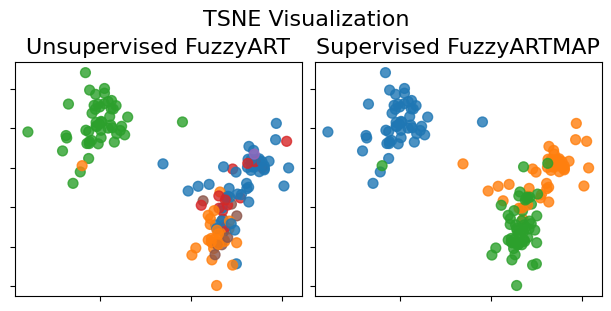

In [17]:
# Preprocess the data (normalize and complement code)
test_X_prep = model.prepare_data(full_data.x)
# Predict data labels
y_hats_supervised = model.predict(test_X_prep)

# Generate the plot
plot_side_by_side_2d(
    S_t_sne.T,                  # The TSNE 2D projections
    y_hats,                     # The clustered labels
    y_hats_supervised,          # The true labels
    "Unsupervised FuzzyART",
    "Supervised FuzzyARTMAP",
    "TSNE Visualization",
)

We see that the supervised model correctly reproduces the structure of data (with the exception of the one sample that we missed earlier, of course) by only predicting three clusters based upon the unique supervised labels provided during training.
Note, this is separate from the number of prototypes/categories used under the hood to represent these three clusters!

## Conclusion

This notebook went over some of the high-level API of the `artlib` library; we looked at unsupervised and supervised variants, batch and incremental learning, and testing and evaluation of these modules in various forms!
Hopefully you learned something from this notebook not just about the `artlib` module but also the usage of ART modules in general.

Check out the [other notebooks](https://art-book-online.github.io/notebooks/) on this site to learn more about getting hands-on with ART algorithms!